# **DSC - 02) Decision Trees**

A flowchart-like structure that uses branching paths to predict the outcomes of events, the probability of certain outcomes, or to reach a decision. They can used for both classification and regression problems. Tree-based modelling is the base of a wide variety of machine learning algorithms.

**References:**  
> [Statquest](https://www.youtube.com/watch?v=_L39rN6gz7Y)  
> [Google Advenced Data Analytics](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/supplement/zShQK/explore-decision-trees)

## **2.0) Theoretical Backgroud**

### **2.0.1) Terminology**

Each node of a decision tree can be labeled as follows:

> **Root Node**  
> *Only have arrows pointing away from it*  
> The very top of the decision tree and represents the entire dataset. THis node contains the initial splitting criterion (or decision rule) that divides the dataset into subsets. It's the starting point for traversing the tree and the most meaningful decision should be placed here.

> **Decision Node**  
> *Have both arrows pointing towards it and away from it*  
> These are intermediate nodes that represent decision points where the data is furtger split based on specific criteria. Each decision node is asssociated with a feature and a condition. These nodes hace one or more child nodes (branches).  

> **Leaf Node**  
> *Only have arrows pointing to it*  
> Represent the endpoints of the tree. They provide the final output or classification/prediction for that path. In a classification tree they represent a single class label. In regression trees they represent a numerical prediction.  

### **2.0.2) Splitting of variables**

**Categorical Variables**  
> All examples in this noteboom  depict nodes that split into just two child nodes, because this is how they are implemented in modeling libraries. A two-level binary split is functionally equivalent to a single-level three-way split, but much simple in terms of computtional demand.

**Continuous variables**  
> If the predictor variable is continuous, splits can be made anywhere along the range of numbers that exist in the data. Often the potential split points are determined by sorting the values for the feature and taking the mean of each consecutive pair of values. However, there can be any number of split points, and fewer split points can be considered to save computational resources and time. It is very common, especially when dealing with very large ranges of numbers, to consider split points along percentiles of the distribution.


### **2.0.3) Impurity of a leaf node**

In a classification treee, when a leaf node has mixed possible outcomes, it's called _impure_. Otherwise, whe the parent decision node results in a leaf node where the subset results in an unique label, is called _pure_. Note that a decision node (a branch) might result in a pure and in a impure leaves at the time.

**Measuring the impurity**  
There are multiple methods for measuring the impurity of leaves. The most populars are:

> **Gini impurity**  
Is computed for each leaf node, and captures oh well splitted the data is, based on the decision taken in the parent node.  
> $\displaystyle Gini \; impurty \; score = 1 - \sum^{N}_{i=1} P(i)^2$  
> $where: \quad N= \textit{Number of classes in the response variable}$

> **Average Weighted Gini Impurity**  
> To compute the resultant purity of a decision node, the Gini Impurity Score of the child nodes are aggregated based on the number of observations that are used in each of the leaf nodes (child nodes).

> **Information gain**  
> There are other methods to assess the impurity of a leaf node such as the _Information Gain_ or the _Entropy_, but these are not discussed here.

### **2.0.4) When to use**

As every other algorithm or techinque, tree-based modelling comes with a series of pros and cons that are discussed here.

> **Advantages**
> 1) Simple to understand and interpret
> 2) No need  for data normalization or scaling
> 3) Handles both numerical and categorical data
> 4) Naturally considers eature importance
> 5) Makes no assumption of the underlying distribution (non parametrical)
> 6) Handles missing values
> 7) Fast to train and predict

> **Disadvantages**
> 1) Prune to overfitting
> 2) Non-robust method (instability)
> 3) Biased splits
> 4) High variance

### **2.0.5) Evaluation metrics**

**Accuracy**
> _Definition:_ The proportion of correct prediction (both trye positives and true negatives) out of the total number of predictions  
> _When to use:_ Useful when the dataaset is balanced (equal or ner.equal class distribution)  
> _Limitations:_ Can be misleading for imbalanced datasets  
> 
> $Accuracy = \dfrac{TP+TN}{TP+FP+TN+FN}$

**Precision**
> _Definition:_ The proportion of correctly predicted positive instances out of all predicted positive instances
> _When to use:_ Import in scenarios where false positives are costly (e.g., spam email classification)
> _Trade-Off:_ Higher precision often comes at the cost of lower recall
>
> $Precision = \dfrac{TP}{TP+FP}$

**Recall / Sensitivity**  
> _Definition:_ The proportion of correctly predicted positive instances out of all actual positive instances.
> _When to use:_  Crucial when false negatives are costly (e.g.g, disease detection)
> _Trade-Off:_ Hiugher recall can lead to lower precision
>   
> $Recall = \dfrac{TP}{TP+FN}$

**F1-Score**  
> _Definition:_ The harmonic mean of precision and recall balancing the two
> _When to use:_ Suitable for imbalanced datasets where both precision and recall are important
>
> $F1-Score = 2 \cdot \dfrac{Precision \cdot Recall}{Precision + Recall}$

**Specifity**
> _Definition:_ THe proportion of correctly predicted negative instances out of all actual negative instances  
> _When to use:_ Relevant when identifying negatives is as important as positives (e.g. fraud detecion).
>
> $Specifity?=\dfrac{TN}{TN+FP}$

### **2.0.6) Averaging methods for multiclass evaluation**

Wvaluation metrics discussed previously are formulated for binary respones. When dealing with multiclass variables, only the accuracy score can be computed without any further consideraiton. For the rest of them, there are averaging schemes to compute the evaluation scores.

**Macro Average**  
> _Description:_ The score for each class is calculated independetly (splitted in a binary form), and the average of this per class-scores is taken. All classes are weighted equally.
>
> _When to use:_ Used when you want to treat each class equally, regardless of its frequency in the data.
>   
> $Macro \; Average = \dfrac{1}{C} \displaystyle \sum^{C}_{i=1} Score_i$

**Micro Average**
> _Description:_ Calculates global pscores by aggregating the contributions of all classes into a single confusion matrix. It is not class.specific and treats all predictions equally.ions equally.
>  
> _When to use:_ When you want to treat all predictions equally, regardless of their class distribution. 
>
> $Micro \; Averaging \; (Precision)= \displaystyle \frac{\sum_{i=1}^{C} TP_i}{\sum_{i=1}^{C} TP_i + FP_i}$

**Wheigted Average**  
> The score of each class is weighted by the number of True instances (support) ($n_i$) of the class. This takes into account the frequency of each class.  
>
> $Weighted \; Average = \dfrac{1}{N} \displaystyle \sum^C_{i=n} n_i \cdot Score_i$
>   
> _When to use:_ Useful when you want to give more importance to classes that appear more frequently in the dataset


### **2.0.6) Hypermaraters involved**

Hyperparameters define the shape of the algorithm, dictates the restrictions or assumptions taken when running the model. The control their strucgture, training process, and ability to generalize to unseen data. Tuning these correctly yields an increase in performance when predicting or classifying new data. Hyperparametr tuning is the process of adjustin the parameters to find the values that result in the most optimal model. In order to find the optimar values for the hyperparameters, a GridSearch is performed. This involves fitting all the possible models and select the one with the best performance.

**Tree structure control**  
> _max_depth:_ Sets the maximum depth of the tree. Limiting the depth prevents the ree from growing too large, reducing the risk of everfitting. Smaller values might lead to underfitting.
>
> _min_samples_split_:_ The minimum of samples required to split an internal node. Higher values prevent the tree from splitting too much and can help with generalization.
>
> _min_samples_leaf:_ The minumum number of samples that a leaf node must have. Ensures that leaf nodes habe enough data, reducing overfitting.
>
> _max_features:_ The maximum number of features to consider when determining the best split. Restricting the features can make the tree more robust and less prone to overfitting
>
> _max_leaf_nodes:_ Limits the total number of leaf nodes in the tree. This constraint can help simplify the model and prevent overfitting.
>
> _min_impurity_decrease_:_ Text

**Splitting criteria**  
> _Classification_:_ Use the Gini Impurity Score, Entropy, etc.
>
> _Regression_:_ Use the SSE (_sum of squared errors_), MSE (_mean squared error_), MAE (_mean absolute error_), etc.

**Regularization parameter and stopping criteria**  
> _ccp_alpha:_  The complexity parameter used for pruning trees. A larger value will result in a simpler tree, as it penalizes the addition of branches
>  
> _min_weight_fraction_leaf:_ The minimum weighted fraction of the total number of samples required to be at a leaf node. Helps in balancing datasets with large class imbalance.


### **2.0.7) Model validation**

The main purpose of a trian - test split is to use the test dataset to evaluate the performance of the model. Nevertheless, there's still the necessity to _VALIDATE_ such model, which is a more rigorous way to train and select a model. The test data should only be used to evaluate the final model. By selecting the model that performs best on the test data, you never get a truly obkective measure of future performance. The measure would be optimistic.

The selection of the final model would itself behave as a tuning process, because you'd be using the test data to go back and make an upstream decision about your model. Put simply, if you want to use the test data to het a true measure of future performance, the you must never use it to make a modeling choice. Only use the test data to evaluate the final model.

**Validation sets**

> The simplest way to mantain the objectiviy of the test data is to create another partition in the data, a validation set, and save the test data for after you select the final model. The validation set is then used, instead of the test set, to compare different models. This method, using a separate validation set to compare models, is most commonly used when you have a very large dataset. The reasen for this is that the more data you use for validation, the less youu have for training and testing.  An usual way to split the data is: 60% tran, 20% validate, and 20% test. 

**Cross Validation**
> Makes more efficient use of the training data by splitting the training data into _k_ number of "folds" (partitions), training a model on $k-1$ folds, and using the fold that was held out to get a validation score. At the end, the final validation score is the average of all $k$ scores. This process is also commonly referred as _k-fold cross validation_.
>
> After a model is selected using cross-validation, that selected model is then refit to the entire training set.
>
> THe corss-validation process maximizes the usefulness of your data with the goal of getting a more accurate measure of model performance. It does so by averagin the randomness imparted when splitting into trainining and validation folds.  It also reduces the likelihood of significant divergence of gthe distributions in the validation data from those in the full dataset. The more folds you use, the more thorough the validation. 

## **2.1) Prepare for execution**

### **2.1.1) Load needed libraries**

In [7]:
# General purpose
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
from sklearn import datasets

# Used for modelling
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

# Used to perform multidimensional scaling
from sklearn.manifold import MDS
import scipy.spatial.distance as distance
from sklearn.metrics import pairwise

# Used for ANOVA test
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Assess the fitted model
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

# Model selection
from sklearn.model_selection import GridSearchCV

### **2.1.2) Used dataset**

#### **2.1.2.1) Load data**

In [8]:
# Load dataset
sk_wine = datasets.load_wine()
df_data = pd.DataFrame(data=sk_wine.data, columns=sk_wine["feature_names"])
df_data["wine_type"] = pd.Series(sk_wine["target"]).map({0:"cabernet", 1:"merlot", 2:"shiraz"})
df_data.rename({"od280/od315_of_diluted_wines": "protein"}, axis=1, inplace=True)
features = df_data.columns.to_list()
features.remove("wine_type")

# Block breaker
print("="*100, "\nTarget variable distribution in the dataset:","\n")
print(df_data["wine_type"].value_counts(normalize=True).round(3))
print("="*100)

Target variable distribution in the dataset: 

wine_type
merlot      0.399
cabernet    0.331
shiraz      0.270
Name: proportion, dtype: float64


#### **2.1.2.2) Exploratory data analysis**

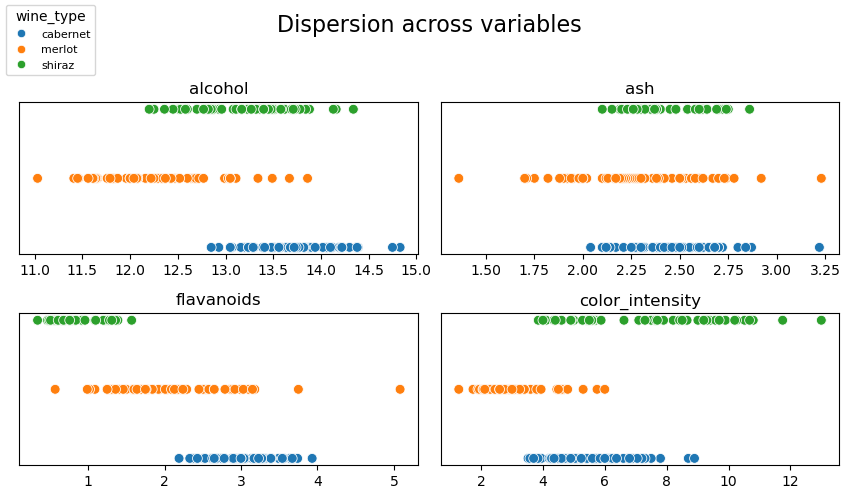

In [9]:
# Used to extract legend to be displayed later
scatter_ax = plt.gca()
sns.scatterplot(data=df_data, x="alcohol", y="wine_type", hue="wine_type", ax=scatter_ax)
handles, labels = scatter_ax.get_legend_handles_labels()
plt.close()

# Plot grid of charts
fig, axes = plt.subplots(2, 2, figsize=(8.5,5))
variables = ["alcohol", "ash", "flavanoids", "color_intensity"]
for i, ax in enumerate(fig.axes):
    sns.scatterplot(df_data, x=variables[i], y="wine_type", ax=ax, hue="wine_type", legend=False, s=50)
    ax.set_title(variables[i], fontsize=12), ax.set_ylabel(""), ax.set_yticks([]), ax.set_xlabel(""), ax.set_ylim(-0.1,2.1)

# Add legend, adjust and show plot
plt.suptitle("Dispersion across variables", fontsize=16)
fig.legend(handles, labels, fontsize=8, loc="upper left", ncol=1, title='wine_type')
plt.tight_layout(rect=[0, 0, 1, .95])
plt.show()

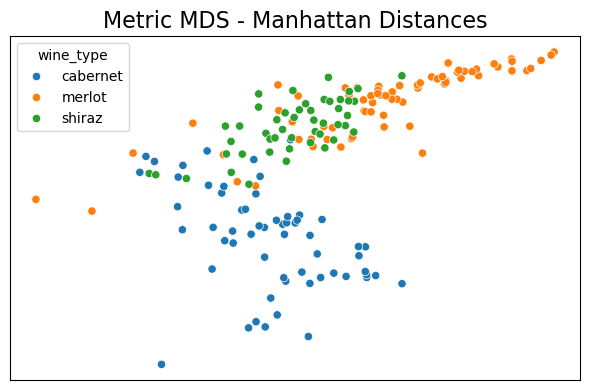

In [10]:
# Calculate NMDS based on city block distances
dissim = pairwise.manhattan_distances(df_data[features])
mds = MDS(n_components=2, dissimilarity="precomputed", metric=True, random_state=314159)
mds = mds.fit_transform(dissim)

# Plot results
plt.figure(figsize=(6,4))
sns.scatterplot(x=mds[:,0], y=mds[:,1], hue=df_data["wine_type"])
plt.title("Metric MDS - Manhattan Distances",fontsize=16), plt.xticks([]), plt.yticks([]), plt.tight_layout()
plt.show()

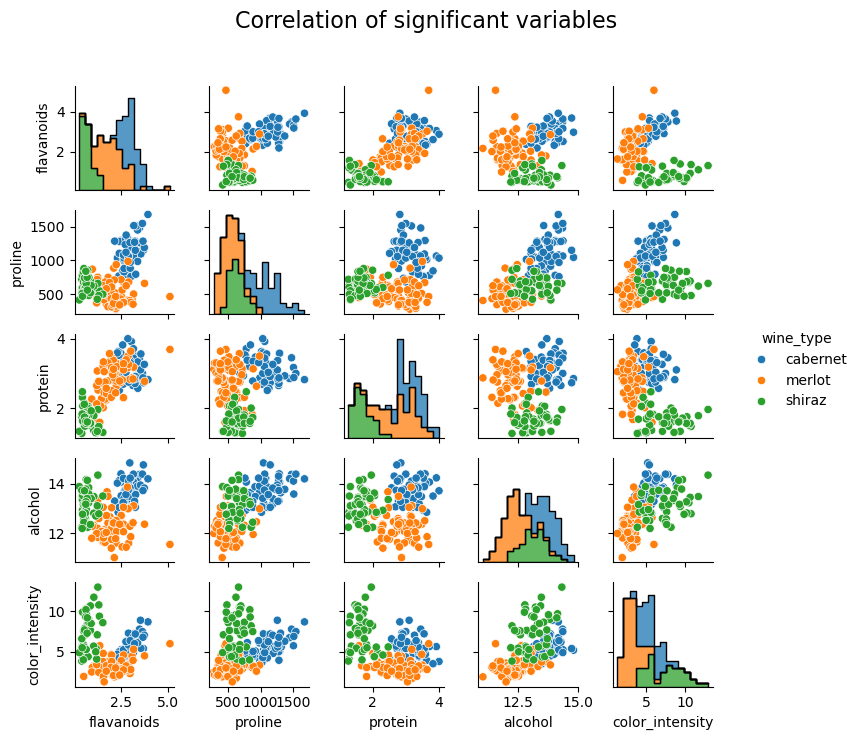

In [11]:
# Scale features using a z-score
df_temporal = (df_data[features] - df_data[features].mean()) / df_data[features].std(ddof=1)
df_temporal = pd.concat([df_temporal, df_data["wine_type"]], axis=1)

# Adjust model and run one way ANOVA to select variables of interest
temporal = {}
for variable in features:
    model_ols = ols(formula=variable+" ~ C(wine_type)", data=df_data).fit()
    temporal[variable] = sm.stats.anova_lm(model_ols, typ=2).iloc[0,3]
variables = pd.Series(temporal).sort_values(ascending=True).index.to_list()[:5]

# Slice df to preserve only variables of interest
df_temporal = df_data[variables+["wine_type"]].copy()

# Correlation plot
grid = sns.PairGrid(df_temporal, hue="wine_type", height=1.5)
grid.map_diag(sns.histplot, multiple="stack", element="step", bins=15), grid.map_offdiag(sns.scatterplot)
grid.add_legend(), grid.fig.suptitle("Correlation of significant variables", fontsize=16), plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

## **2.2) Classification Trees**

### **2.2.1) Fit the model**

In [12]:
# Shape the data
X = df_data[features]
y = df_data["wine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=314159)

# Fit the model and predict test data
model_dtc = DecisionTreeClassifier(random_state=314159)
model_dtc = model_dtc.fit(X_train, y_train)
y_pred = model_dtc.predict(X_test)

# Generate assessment metrics
print("="*100)
print("Accuracy: {:.1%}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.1%}".format(precision_score(y_test, y_pred, average="micro")))
print("Recall: {:.1%}".format(recall_score(y_test, y_pred, average="micro")))
print("F1-Score: {:.1%}".format(f1_score(y_test, y_pred, average="micro")))
print("="*100)

Accuracy: 75.6%
Precision: 75.6%
Recall: 75.6%
F1-Score: 75.6%


### **2.2.2) Inspect confusion matrix**

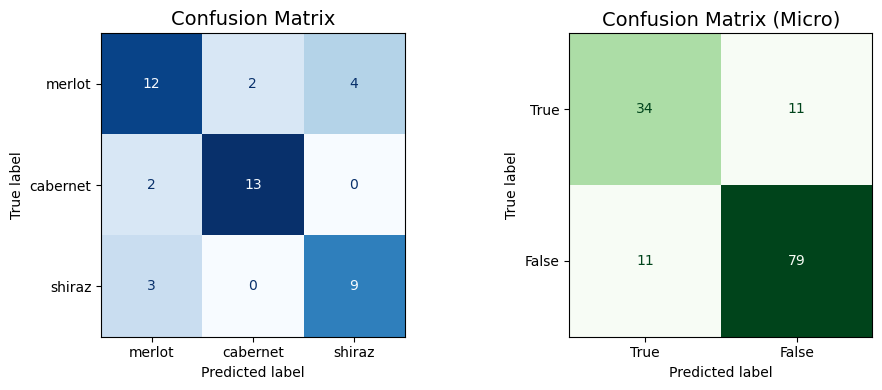

In [13]:
# Set up plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

# Three-way confussion matrix
conf_mx = confusion_matrix(y_test, y_pred, labels=y_test.unique())
ConfusionMatrixDisplay(conf_mx, display_labels=y_test.unique()).plot(colorbar=False, cmap="Blues", ax=ax1)
ax1.set_title("Confusion Matrix", fontsize=14)

# Micro aggregated confusion matrix
labels = [True, False]
wine_types = ["merlot", "cabernet", "shiraz"]
conf_mx = np.array([[0,0], [0,0]])
for wine_type in wine_types:
    conf_mx = conf_mx + confusion_matrix((y_test==wine_type), (y_pred==wine_type), labels=labels)

# Plot micro aggregated confusion matrix
ConfusionMatrixDisplay(conf_mx, display_labels=labels).plot(colorbar=False, cmap="Greens", ax=ax2)
ax2.set_title("Confusion Matrix (Micro)", fontsize=14)

plt.tight_layout()
plt.show()

### **2.2.3) Plot decision tree**

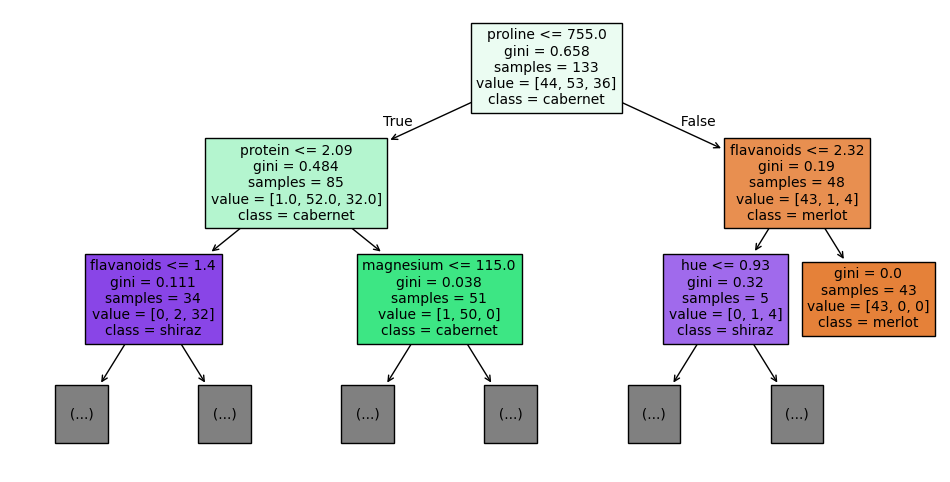

In [14]:
# Plot decision tre
plt.figure(figsize=(12,6))
plot_tree(model_dtc, max_depth=2, feature_names=X.columns, class_names=y_test.unique(), filled=True, fontsize=10)
plt.show()

## **2.3) Regression Trees**

Tree-based modelling for regression purposes is specially useful when a linear trend cannot be fitted well on the data. Instead of returing a class name for the subset in the leaf node, it usually returns the average of the response variable of the elements in the subset. Instead of using an impurity score, the quality of each leave is assessed with the sum of squared residuals. 

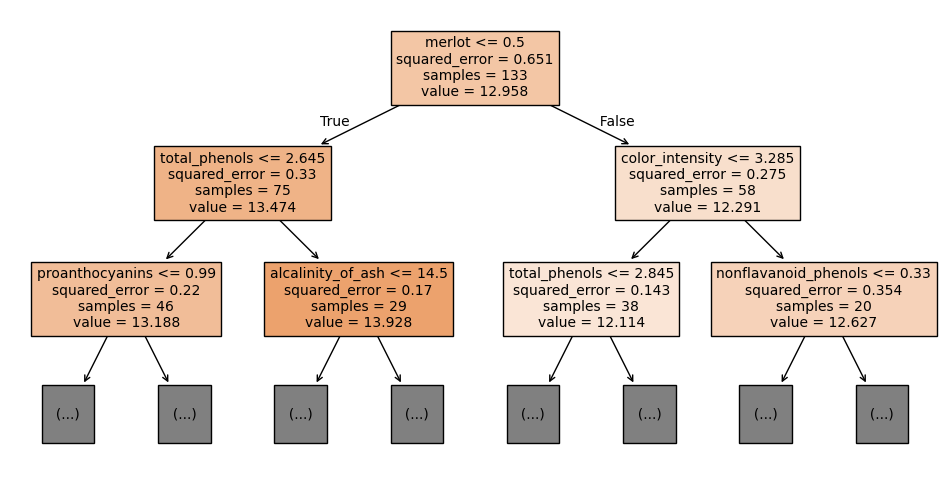

In [15]:
# Shape the data
X = pd.concat([df_data[features], pd.get_dummies(df_data["wine_type"]).astype(int)], axis=1).drop(["alcohol"], axis=1)
y = df_data["alcohol"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=314159)

# Build model
model_dtr = DecisionTreeRegressor(random_state=314159).fit(X_train, y_train)

# Plot decision tree regressor
plt.figure(figsize=(12,6))
plot_tree(model_dtr, max_depth=2, feature_names=X.columns, class_names=y_test.unique(), filled=True, fontsize=10)
plt.show()

## **2.4) Hyperparameter tuning**

In [16]:
# Shape data
X = df_data[features]
y = df_data["wine_type"]
X_train, X_temporal, y_train, y_temporal = train_test_split(X, y, test_size=0.40, stratify=y, random_state=314159)
X_test, X_validate, y_test, y_validate = train_test_split(X_temporal, y_temporal, test_size=0.40, stratify=y_temporal,random_state=314159)

# Define hyperparameters to iterate over and scoring metrics to retain in the iteration process
tree_params = {"max_depth": [2,3,4,5], "min_samples_leaf":[2,3,4,5], "min_samples_split": [2,3,4,5]}
scoring_metrics = ["precision_micro"]

# Perform Grid Search of best params
model_dt = DecisionTreeClassifier(random_state=314159)
grid_dt = GridSearchCV(estimator=model_dt, param_grid=tree_params, scoring="f1_micro", refit=True)
grid_dt = grid_dt.fit(X_train, y_train)
y_pred = grid_dt.predict(X_test)

# Print block breaker
print("="*100)
print("Best parameters:")
print(grid_dt.best_params_)
print("="*100)

# Generate assessment metrics
print("="*100)
print("Accuracy: {:.1%}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.1%}".format(precision_score(y_test, y_pred, average="macro")))
print("Recall: {:.1%}".format(recall_score(y_test, y_pred, average="micro")))
print("F1-Score: {:.1%}".format(f1_score(y_test, y_pred, average="micro")))
print("="*100)

Best parameters:
{'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 2}
Accuracy: 79.1%
Precision: 79.8%
Recall: 79.1%
F1-Score: 79.1%
